In [ ]:
import numpy as np
import astropy.units as u
from astropy.io import fits
import time 
from importlib import reload
import copy
from datetime import datetime
today = int(datetime.today().strftime('%Y%m%d'))

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize, CenteredNorm
from matplotlib.patches import Circle, Rectangle

import scoob_llowfsc
print(scoob_llowfsc.path)
data_path = scoob_llowfsc.path/'exp-data'

from scoob_llowfsc.math_module import xp, xcipy, ensure_np_array
from scoob_llowfsc.imshows import imshow1, imshow2, imshow3, imshow
from scoob_llowfsc import utils
from scoob_llowfsc import iefc
from scoob_llowfsc import telem
import scoob_llowfsc.scoob_interface as scoobi

from magpyx.utils import ImageStream

import purepyindi
from purepyindi import INDIClient
import purepyindi2
from purepyindi2 import IndiClient
client0 = INDIClient('localhost', 7624)
client0.start()
client = IndiClient()
client.connect()
client.get_properties()

wavelength_c = 633e-9



/opt/conda/envs/km310env/lib/python3.10/site-packages/cupyx/jit/_interface.py:173: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')


Could not import deepdish!
Could not import ray. Parallelized model unavailble.
/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc


In [155]:
scoobi.move_psf(-1, 0, client0)

In [150]:
scoobi.move_psf(0, -1, client0)

In [105]:
reload(scoobi)
xc, yc = (4200, 2950)
xc, yc = (4000, 2700)
npsf = 256
scoobi.set_camsci_roi(xc, yc, npsf, client0)


Set CAMSCI ROI.


In [54]:
xc, yc = (3600, 3850)
npsf = 256
scoobi.set_camsci_roi(xc, yc, npsf, client0)


Set CAMSCI ROI.


In [109]:
scoobi.set_camsci_exp_time(0.005, client0)
scoobi.set_camsci_gain(120, client0)

Set the CAMSCI exposure time to 5.00e-03s
Set the CAMSCI gain setting to 120.0


In [119]:
scoobi.set_fib_atten(0, client)

Set the fiber attenuation to 0.0


In [26]:
scoobi.set_camsci_blacklevel(1, client0)

Set the CAMSCI blacklevel to 1.0


0


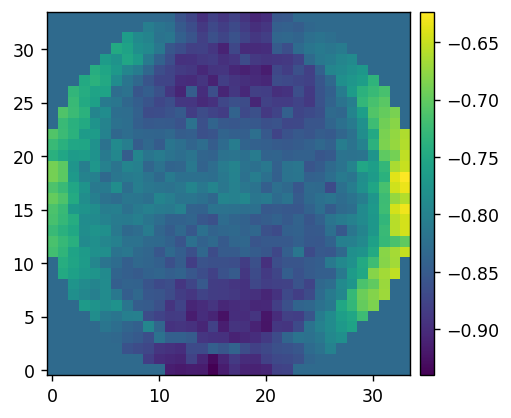

In [56]:
dm_total_stream = ImageStream('dm00disp')

new_flat = dm_total_stream.grab_latest()
imshow([new_flat])

0


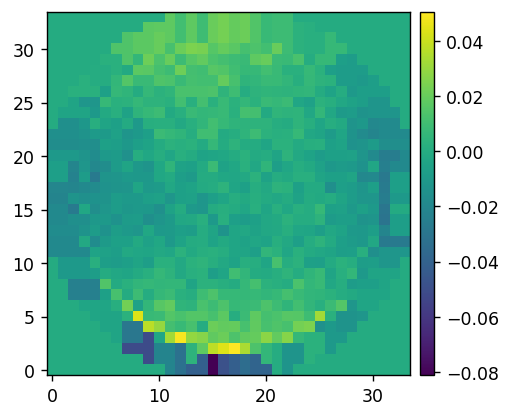

In [ ]:
dm_fdpr_stream = ImageStream('dm00disp03')
flat_update = dm_fdpr_stream.grab_latest()
imshow([flat_update])


In [158]:
dm_fdpr_stream.write(np.zeros((34,34)))

In [60]:
utils.save_fits('20250324_flat_update.fits', flat_update)

Saved data to:  20250324_flat_update.fits


In [57]:
utils.save_fits('20250324_flat.fits', new_flat)

Saved data to:  20250324_flat.fits


In [157]:
dm_fdpr_stream.write(flat_update)